# Perfiles de alto peso relativo y costo en egresos hospitalarios (GRD)

**Integrantes:** Josefa Lara, Catalina Toledo

**Curso:** Análisis de Datos e Inferencia Estadística

**Fuente:** DEIS / MINSAL, egresos hospitalarios (GRD) y tablas maestras del proyecto.

Este cuaderno cumple la estructura mínima del *Segundo Avance*: introducción, carga y limpieza, EDA completo con visualizaciones, test de hipótesis, regresión lineal múltiple e interpretación, conectado con la **pregunta 1** del proyecto.

## Glosario y definición operativa de variables

| Variable | Rol | Definición |
|----------|-----|------------|
| **IR_29301_PESO** | Dependiente / consumo relativo | Peso relativo del GRD (referencia de sistema ≈ 1,0). |
| **IR_29301_COD_GRD** | Perfil de egreso | Código GRD del grupo homogéneo. |
| **PROCEDIMIENTO** | Etiqueta GRD | Descripción desde tabla maestra (hoja `IR - GRD`). |
| **IR_29301_SEVERIDAD** | Perfil clínico (ordinal 1–4) | Severidad APR-DRG; agrupación para contraste de medias y regresión. |
| **DIAS_ESTADIA** | Duración | Días entre `FECHAALTA` y `FECHA_INGRESO`. |
| **EDAD** | Sociodemográfica | Años cumplidos aproximados al ingreso. **Valor 0** codifica recién nacidos en la base. |
| **SEXO** | Sociodemográfica | Sexo registrado. |
| **COMUNA** | Sociodemográfica | Comuna informada en el registro (nominal). |
| **REGION** | Territorial | Derivada de `PROVINCIA` con diccionario estándar. |
| **COSTO_APROXIMADO** | Costo proxy | `IR_29301_PESO × 400_000` pesos (valorización lineal del peso para comparabilidad monetaria). |
| **ALTO_PESO** | Indicador | `IR_29301_PESO > 1,0`. |
| **ALTO_COSTO** | Indicador | `COSTO_APROXIMADO` ≥ percentil 75 global de la muestra limpia. |
| **SUBGRUPO_ALTO_PE_CO** | Población P1 | Pacientes con **ALTO_PESO** y **ALTO_COSTO** a la vez. |
| **SOBRE_PROMEDIO_PESO** | Criterio / VD auxiliar dicotómica | `IR_29301_PESO > \bar{X}` con $\bar{X}$ la media de `IR_29301_PESO` sobre **toda la base `analisis`** (filtros ya aplicados). Complementario a la norma técnica 1,0. |
| **FRANJA_ETARIA**, **COMUNA** / **_COMUNA_GRP** | Independientes cualitativas | En §5b: **0–1**, **2–17**, **18–39**, **40–59**, **60 y más** (años desde `EDAD`); comuna agrupada `OTROS` en tablas masivas $\\chi^2$. |
| **`FRANJA_ED_DET`** | Edad con RN aparte | **RN** = `EDAD = 0`; el resto usa `EDAD` en años: **1–17**, **18–39**, **40–59**, **60 y más**. |
| **`FRANJA_ETARIA_5`** | Edad (bloque 5d) | Franjas **exclusivas** para cruce con alto costo: **0–1** (`EDAD ≤ 1`), **1–18** (`2–17` años), **18–39**, **40–59**, **60 o más**. |

**Pregunta 1:** ¿Cuál es el perfil sociodemográfico (edad, sexo y comuna) de los pacientes con peso relativo y costo alto?

**Pregunta complementaria:** entre quienes superan la **media muestral del peso relativo**, ¿hay **sobrerrepresentación sistemática** por sexo, franja etaria o comuna respecto del resto de la base?

**Ligazón al contraste inferencial:** el **§6** usa un único **Kruskal–Wallis** sobre **gasto acumulado por beneficiario** (proxy) frente al perfil **sexo × franja etaria**, con complementos descriptivos por comuna y concentración del gasto; el **§7** aplica **MCO episódica** sobre `IR_29301_PESO` con covariables; el bloque `SOBRE_PROMEDIO` usa **tabular $\chi^2$ + V de Cramér + logística sobre submuestra** (`scikit-learn`) para otro tipo de evidencia ante $N$ grande.

## 1. Carga de datos

In [73]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
warnings.filterwarnings("ignore", category=FutureWarning)

CSV_PATH = Path("GRD.csv")
EXCEL_MAESTRAS = Path("Tablas maestras bases GRD.xlsx")

df = pd.read_csv(CSV_PATH, encoding="latin-1", sep=";", engine="python")
print("Dimensiones:", df.shape)
print("N columnas:", df.shape[1])

Dimensiones: (1048575, 129)
N columnas: 129


## 2. Limpieza y preparación de datos

- Selección de variables alineadas con la pregunta de investigación.
- Exclusión de registros sin región mapeable, sin peso numérico válido o con sexo desconocido.
- Recálculo de `DIAS_ESTADIA` y `EDAD` solo cuando las tres fechas clave parsean.
- `COSTO_APROXIMADO` y reglas **ALTO_PESO** / **ALTO_COSTO** documentadas en el glosario.
- Reporte de duplicados exactos en el subconjunto final.

In [74]:
cols = [
    "COD_HOSPITAL",
    "ID_BENEFICIARIO",
    "SEXO",
    "FECHA_NACIMIENTO",
    "PROVINCIA",
    "COMUNA",
    "TIPO_PROCEDENCIA",
    "TIPO_INGRESO",
    "ESPECIALIDAD_MEDICA",
    "TIPO_ACTIVIDAD",
    "FECHA_INGRESO",
    "SERVICIOINGRESO",
    "FECHAALTA",
    "TIPOALTA",
    "ESPECIALIDADINTERVENCION",
    "IR_29301_COD_GRD",
    "IR_29301_PESO",
    "IR_29301_SEVERIDAD",
    "IR_29301_MORTALIDAD",
]

d = df[cols].copy()

REGIONES_Y_PROVINCIAS = {
    "Arica y Parinacota": ["ARICA", "PARINACOTA"],
    "Tarapacá": ["IQUIQUE", "TAMARUGAL"],
    "Antofagasta": ["ANTOFAGASTA", "EL LOA", "TOCOPILLA"],
    "Atacama": ["COPIAPO", "CHAÑARAL", "HUASCO"],
    "Coquimbo": ["ELQUI", "LIMARI", "CHOAPA"],
    "Valparaíso": [
        "PETORCA",
        "LOS ANDES",
        "SAN FELIPE",
        "MARGA MARGA",
        "QUILLOTA",
        "VALPARAISO",
        "SAN ANTONIO",
        "ISLA DE PASCUA",
    ],
    "Metropolitana": ["SANTIAGO", "CORDILLERA", "CHACABUCO", "MAIPO", "MELIPILLA", "TALAGANTE"],
    "O'Higgins": ["CACHAPOAL", "CARDENAL CARO", "COLCHAGUA"],
    "Maule": ["TALCA", "CAUQUENES", "CURICO", "LINARES"],
    "Ñuble": ["DIGUILLÍN", "DIGUILLIN", "PUNILLA", "ITATA"],
    "Biobío": ["CONCEPCION", "ARAUCO", "BIO-BIO", "BIO BIO"],
    "La Araucanía": ["MALLECO", "CAUTIN"],
    "Los Ríos": ["VALDIVIA", "RANCO"],
    "Los Lagos": ["LLANQUIHUE", "OSORNO", "CHILOE", "CHILOÉ", "PALENA"],
    "Aysén": ["COIHAIQUE", "AISEN", "GENERAL CARRERA", "CAPITAN PRAT"],
    "Magallanes": [
        "MAGALLANES",
        "ULTIMA ESPERANZA",
        "TIERRA DEL FUEGO",
        "ANTÁRTICA CHILENA",
        "ANTARTICA CHILENA",
    ],
}

PROVINCIA_A_REGION = {
    prov.strip().upper(): region
    for region, lista in REGIONES_Y_PROVINCIAS.items()
    for prov in lista
}

d["REGION"] = d["PROVINCIA"].astype(str).str.strip().str.upper().map(PROVINCIA_A_REGION)
sin_region = int(d["REGION"].isna().sum())
if sin_region:
    print(f"Filas sin región mapeable (excluidas): {sin_region:,}")
d = d.loc[d["REGION"].notna()].copy()

d = d.loc[d["IR_29301_PESO"].notna()].copy()
d = d.loc[d["IR_29301_PESO"].astype(str).str.strip().str.upper() != "DESCONOCIDO"].copy()

for col in ("FECHA_INGRESO", "FECHAALTA", "FECHA_NACIMIENTO"):
    d[col] = pd.to_datetime(d[col], errors="coerce", dayfirst=True)

d = d.dropna(subset=["FECHA_INGRESO", "FECHAALTA", "FECHA_NACIMIENTO"]).copy()

d["DIAS_ESTADIA"] = (d["FECHAALTA"] - d["FECHA_INGRESO"]).dt.days
d["EDAD"] = (d["FECHA_INGRESO"].dt.year - d["FECHA_NACIMIENTO"].dt.year).astype(int)

d["IR_29301_COD_GRD"] = d["IR_29301_COD_GRD"].astype(str).str.strip()

maestras = pd.read_excel(EXCEL_MAESTRAS, sheet_name="IR - GRD", engine="openpyxl")
maestras["COD_PROCEDIMIENTO"] = maestras["COD_PROCEDIMIENTO"].astype(str).str.strip()
d = d.merge(
    maestras[["COD_PROCEDIMIENTO", "PROCEDIMIENTO"]],
    left_on="IR_29301_COD_GRD",
    right_on="COD_PROCEDIMIENTO",
    how="left",
).drop(columns=["COD_PROCEDIMIENTO"])

d["IR_29301_PESO"] = pd.to_numeric(
    d["IR_29301_PESO"].astype(str).str.replace(",", ".", regex=False),
    errors="coerce",
)
d = d.loc[d["IR_29301_PESO"].notna()].copy()

d["SEXO"] = d["SEXO"].astype(str).str.strip()
d = d.loc[d["SEXO"].str.upper() != "DESCONOCIDO"].copy()

d["IR_29301_SEVERIDAD"] = pd.to_numeric(d["IR_29301_SEVERIDAD"], errors="coerce")
d = d.dropna(subset=["IR_29301_SEVERIDAD"]).copy()
d["IR_29301_SEVERIDAD"] = d["IR_29301_SEVERIDAD"].astype(int)

# Costo proxy y definición de "alto costo" (percentil 75 muestral)
d["COSTO_APROXIMADO"] = d["IR_29301_PESO"] * 400_000.0
q75_costo = d["COSTO_APROXIMADO"].quantile(0.75)
d["ALTO_COSTO"] = d["COSTO_APROXIMADO"] >= q75_costo
d["ALTO_PESO"] = d["IR_29301_PESO"] > 1.0
d["SUBGRUPO_ALTO_PE_CO"] = d["ALTO_PESO"] & d["ALTO_COSTO"]

dup = int(d.duplicated().sum())
print(f"Registros tras limpieza: {len(d):,}")
print(f"Duplicados exactos en subconjunto: {dup:,}")
print(f"Umbral P75 COSTO_APROXIMADO: {q75_costo:,.0f} pesos")
print(f"Casos SUBGRUPO_ALTO_PE_CO: {int(d['SUBGRUPO_ALTO_PE_CO'].sum()):,} ({100 * d['SUBGRUPO_ALTO_PE_CO'].mean():.2f}%)")

analisis = d.dropna(subset=["COMUNA", "DIAS_ESTADIA"]).copy()
analisis["COMUNA"] = analisis["COMUNA"].astype(str).str.strip()
print(f"Registros con comuna y días válidos (analisis): {len(analisis):,}")

Filas sin región mapeable (excluidas): 378
Registros tras limpieza: 1,048,015
Duplicados exactos en subconjunto: 966
Umbral P75 COSTO_APROXIMADO: 4,050,400 pesos
Casos SUBGRUPO_ALTO_PE_CO: 262,647 (25.06%)
Registros con comuna y días válidos (analisis): 1,048,015


## 3. EDA — Estadística descriptiva

Variables relevantes para la pregunta 1 y para el contraste por severidad. Cada tabla se interpreta brevemente bajo la celda siguiente.

In [75]:
num_cols = ["IR_29301_PESO", "COSTO_APROXIMADO", "DIAS_ESTADIA", "EDAD"]
desc_global = analisis[num_cols].describe(percentiles=[0.25, 0.5, 0.75, 0.9]).T
display(desc_global.round(3))

print("Frecuencias SEVERIDAD (toda la muestra analisis):")
display(
    analisis["IR_29301_SEVERIDAD"]
    .value_counts()
    .sort_index()
    .rename("n")
    .to_frame()
    .assign(pct=lambda x: (100 * x["n"] / x["n"].sum()).round(2))
)

print("Sexo — toda la muestra:")
display(analisis["SEXO"].value_counts(dropna=False))

sub = analisis.loc[analisis["SUBGRUPO_ALTO_PE_CO"]].copy()
print(f"\n--- Subgrupo P1: ALTO peso y ALTO costo — n = {len(sub):,} ---")
if len(sub) > 0:
    display(sub[num_cols].describe(percentiles=[0.25, 0.5, 0.75]).T.round(3))
    display(sub["SEXO"].value_counts(normalize=True).mul(100).round(2).rename("pct"))
    top_com = sub["COMUNA"].value_counts().head(15)
    print("Top 15 comunas en el subgrupo (conteo):")
    display(top_com)
else:
    print("Sin filas en el subgrupo con los filtros actuales.")

,count,mean,std,min,25%,50%,75%,90%,max
IR_29301_PESO,1048015.0,5.567,11.966,0.0,0.48,0.692,10.126,15.316,2.064610e+02
COSTO_APROXIMADO,1048015.0,2226708.214,4786549.351,0.0,192160.00,276600.000,4050400.000,6126400.000,8.258440e+07
DIAS_ESTADIA,1048015.0,5.697,12.139,0.0,1.00,2.000,6.000,14.000,6.610000e+02
EDAD,1048015.0,46.066,25.531,0.0,27.00,47.000,68.000,79.000,1.090000e+02


Frecuencias SEVERIDAD (toda la muestra analisis):


,n,pct
IR_29301_SEVERIDAD,,
0,204020,19.47
1,373970,35.68
2,259782,24.79
3,210243,20.06


Sexo — toda la muestra:


SEXO
MUJER     610466
HOMBRE    437549
Name: count, dtype: int64


--- Subgrupo P1: ALTO peso y ALTO costo — n = 262,647 ---


,count,mean,std,min,25%,50%,75%,max
IR_29301_PESO,262647.0,19.821,17.172,10.126,11.424,14.183,19.386,2.064610e+02
COSTO_APROXIMADO,262647.0,7928352.680,6868922.902,4050400.000,4569600.000,5673200.000,7754400.000,8.258440e+07
DIAS_ESTADIA,262647.0,11.467,19.304,0.000,2.000,6.000,13.000,6.610000e+02
EDAD,262647.0,53.660,25.677,0.000,37.000,61.000,73.000,1.060000e+02


SEXO
HOMBRE    51.58
MUJER     48.42
Name: pct, dtype: float64

Top 15 comunas en el subgrupo (conteo):


COMUNA
PUENTE ALTO     10535
MAIPU            6460
VALPARAISO       5836
LA FLORIDA       5675
SANTIAGO         5385
LOS ÁNGELES      5188
VIÑA DEL MAR     5186
PUERTO MONTT     4698
TALCA            4232
TEMUCO           4110
ANTOFAGASTA      4079
LA SERENA        4059
ARICA            4023
COQUIMBO         3910
PEÑALOLÉN        3718
Name: count, dtype: int64

**Interpretación (global):** el peso relativo concentra masa en valores bajos con cola derecha larga (media >> mediana típica). **Subgrupo P1:** sobre pacientes con `IR_29301_PESO > 1` y costo proxy en el cuarto superior, se resume edad, sexo y comunas más frecuentes: eso responde directamente a la pregunta 1 de forma descriptiva.

## 4. EDA — Visualizaciones

Histograma y boxplot del peso (recorte visual al percentil 99 para el histograma), boxplot de peso por severidad, barras de sexo en el subgrupo P1, y top comunas.

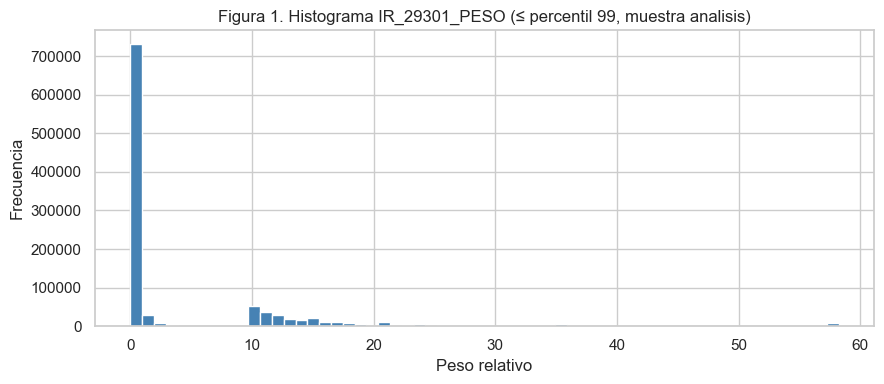

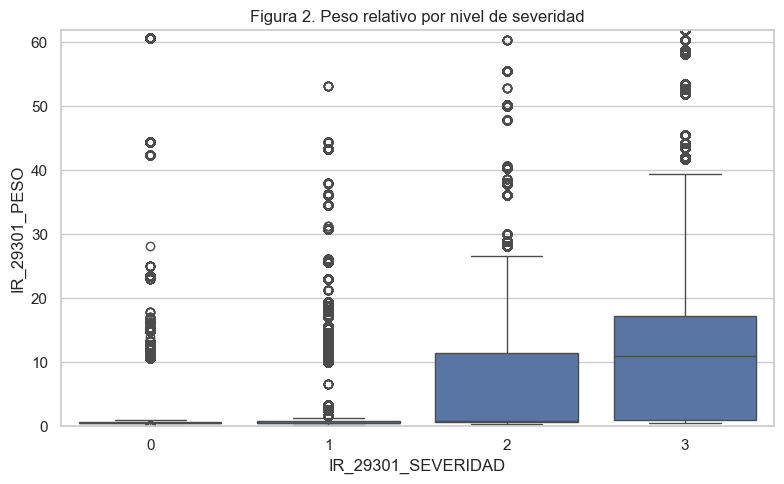

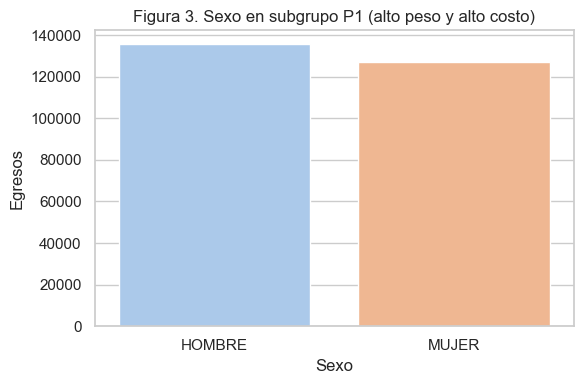

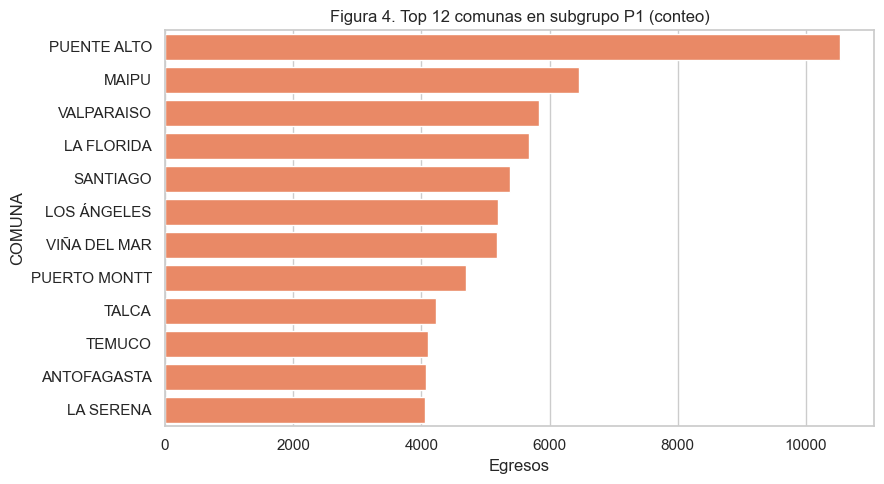

In [76]:
p99 = analisis["IR_29301_PESO"].quantile(0.99)
peso_plot = analisis.loc[analisis["IR_29301_PESO"] <= p99, "IR_29301_PESO"]

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(peso_plot, bins=60, color="steelblue", edgecolor="white")
ax.set_title("Figura 1. Histograma IR_29301_PESO (≤ percentil 99, muestra analisis)")
ax.set_xlabel("Peso relativo")
ax.set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=analisis, x="IR_29301_SEVERIDAD", y="IR_29301_PESO", ax=ax)
ax.set_ylim(0, analisis["IR_29301_PESO"].quantile(0.995))
ax.set_title("Figura 2. Peso relativo por nivel de severidad")
ax.set_xlabel("IR_29301_SEVERIDAD")
ax.set_ylabel("IR_29301_PESO")
plt.tight_layout()
plt.show()

sub1 = analisis.loc[analisis["SUBGRUPO_ALTO_PE_CO"]].copy()
if len(sub1) > 0:
    fig, ax = plt.subplots(figsize=(6, 4))
    order = sub1["SEXO"].value_counts().index
    sns.countplot(data=sub1, x="SEXO", order=order, ax=ax, palette="pastel")
    ax.set_title("Figura 3. Sexo en subgrupo P1 (alto peso y alto costo)")
    ax.set_xlabel("Sexo")
    ax.set_ylabel("Egresos")
    plt.tight_layout()
    plt.show()

    topn = min(12, sub1["COMUNA"].nunique())
    if topn > 0:
        tc = sub1["COMUNA"].value_counts().head(topn)
        fig, ax = plt.subplots(figsize=(9, 5))
        sns.barplot(x=tc.values, y=tc.index, ax=ax, orient="h", color="coral")
        ax.set_title(f"Figura 4. Top {topn} comunas en subgrupo P1 (conteo)")
        ax.set_xlabel("Egresos")
        plt.tight_layout()
        plt.show()

## 5. Relaciones entre variables (pregunta e hipótesis)

Correlación de Pearson entre variables numéricas principales y contraste visual peso–días por severidad (muestra recortada a días ≤ P99.5 para claridad).

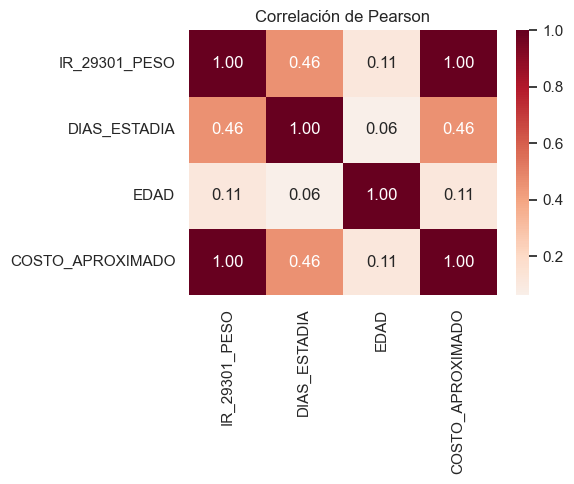

Peso-estadía: N=1,048,015 | Spearman ρ ≈ 0.4152, p <1e-300
   IR_29301_PESO≤0: 0.13% | días<0 (revisión de fechas): 0.00%


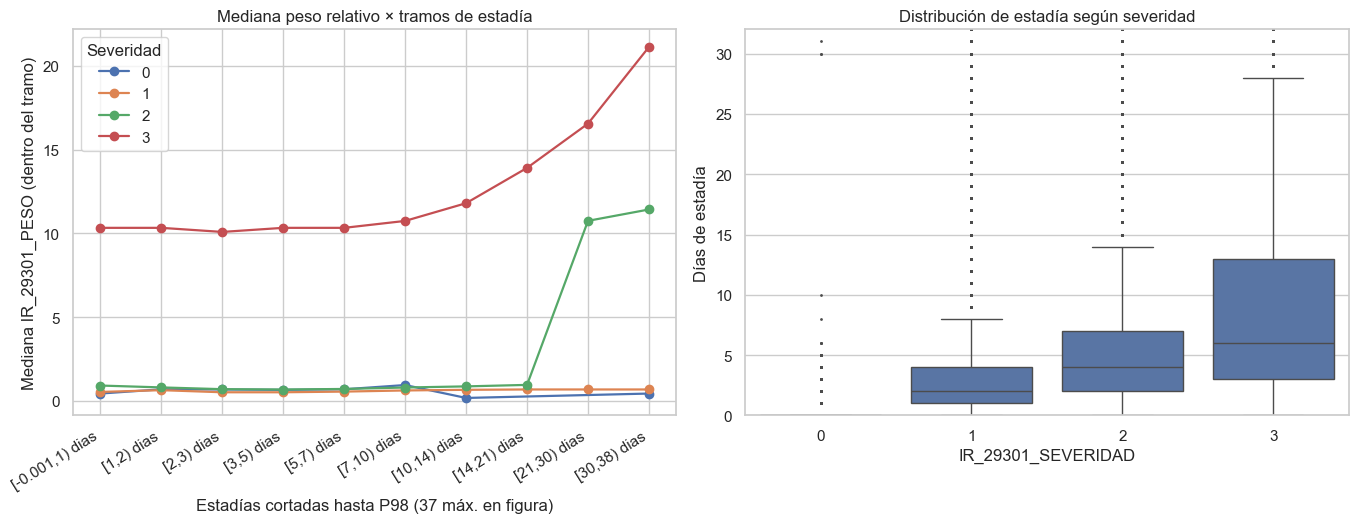

In [77]:
num_for_corr = analisis[["IR_29301_PESO", "DIAS_ESTADIA", "EDAD", "COSTO_APROXIMADO"]].dropna()
cm = num_for_corr.corr(method="pearson")
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Correlación de Pearson")
plt.tight_layout()
plt.show()

# Peso vs estadía: el GRD fuerza niveles discreto de peso; la dispersión cruda suele parecer caótica.
# Mejor lectura: mediana de peso en tramos clínicos de estadía (+ boxplot paralelo estadía × severidad).

_base = analisis[["DIAS_ESTADIA", "IR_29301_PESO", "IR_29301_SEVERIDAD"]].dropna()
_pct0p = 100 * (_base["IR_29301_PESO"] <= 0).mean()
_pct0d = 100 * (_base["DIAS_ESTADIA"] < 0).mean()
rho_s, p_rho_s = stats.spearmanr(_base["DIAS_ESTADIA"], _base["IR_29301_PESO"])
_pfmt = "<1e-300" if p_rho_s < 1e-300 else f"{p_rho_s:.2e}"
print(
    f"Peso-estadía: N={len(_base):,} | Spearman ρ ≈ {rho_s:.4f}, p {_pfmt}\n",
    f"  IR_29301_PESO≤0: {_pct0p:.2f}% | días<0 (revisión de fechas): {_pct0d:.2f}%",
)

_core = _base.loc[_base["IR_29301_PESO"] > 0].copy()
cap_d = float(_core["DIAS_ESTADIA"].quantile(0.98))
_v = _core.loc[_core["DIAS_ESTADIA"] <= cap_d].copy()

_edges = [-0.001, 1, 2, 3, 5, 7, 10, 14, 21, 30]
if float(cap_d) > _edges[-1]:
    _edges.append(float(cap_d) + 1)
_v["tramo_estadia"] = pd.cut(
    _v["DIAS_ESTADIA"].astype(float),
    bins=_edges,
    right=False,
)
_summ = (
    _v.groupby(["IR_29301_SEVERIDAD", "tramo_estadia"], observed=True)["IR_29301_PESO"]
    .agg(mediana="median", n="count")
    .reset_index()
)
_cats = _v["tramo_estadia"].astype("category").cat.categories
_tramo_cod = {c: float(i + 1) for i, c in enumerate(_cats)}
_summ["orden_tramo"] = _summ["tramo_estadia"].map(_tramo_cod)
_etiq = ["[{0:g},{1:g}) dias".format(float(iv.left), float(iv.right)) for iv in _cats]

fig, axes = plt.subplots(1, 2, figsize=(13.8, 5.4))

for sev in sorted(_summ["IR_29301_SEVERIDAD"].unique()):
    sub = _summ.loc[_summ["IR_29301_SEVERIDAD"] == sev].sort_values("orden_tramo")
    if len(sub):
        axes[0].plot(
            sub["orden_tramo"].to_numpy(dtype=float),
            sub["mediana"].to_numpy(dtype=float),
            marker="o",
            linewidth=1.6,
            label=str(sev),
        )
_nx = np.arange(1, len(_cats) + 1)
axes[0].set_xticks(_nx)
axes[0].set_xticklabels(_etiq, rotation=32, ha="right")
axes[0].set_ylabel("Mediana IR_29301_PESO (dentro del tramo)")
axes[0].set_xlabel(f"Estadías cortadas hasta P98 ({cap_d:.0f} máx. en figura)")
axes[0].legend(title="Severidad", loc="best")
axes[0].set_title("Mediana peso relativo × tramos de estadía")

sns.boxplot(
    ax=axes[1],
    data=_v,
    x="IR_29301_SEVERIDAD",
    y="DIAS_ESTADIA",
    fliersize=1,
    linewidth=1,
    order=sorted(_v["IR_29301_SEVERIDAD"].unique()),
)
axes[1].set_title("Distribución de estadía según severidad")
axes[1].set_xlabel("IR_29301_SEVERIDAD")
axes[1].set_ylabel("Días de estadía")
qi, qs = (
    float(_v["DIAS_ESTADIA"].quantile(0.01)),
    float(_v["DIAS_ESTADIA"].quantile(0.993)),
)
axes[1].set_ylim(qi, qs)

plt.tight_layout()
plt.show()

## 5b. Peso relativo **sobre el promedio muestral** (`SOBRE_PROMEDIO`) — perfil y evidencia inferencial

Este bloque cumple el esquema habitual del *Avance 2* (definición explícita de **variable dependiente** vs **independientes**, descriptivo comparado y pruebas coherentes con el tipo de datos).

### Formulación (`Requerimientos_Avance2`)

| Rol | Variable operativa | Interpretación |
|-----|-------------------|----------------|
| **VD (respuesta analítica focal)** | **`SOBRE_PROMEDIO`** = 1 si `IR_29301_PESO` > $\bar{X}$ con $\bar{X}$ el promedio muestral en `analisis` | Selecciona el subconjunto con **consumo relativo por encima del promedio observado** tras la limpieza estándar del cuaderno (no confundir con `ALTO_PESO` > 1,0 ni con el subgrupo alto costo). |
| **VI categóricas** | **`SEXO`**, **`FRANJA_ETARIA`** (**0–1**, **2–17**, **18–39**, **40–59**, **60+** años), **`REGION`**, **`_COMUNA_GRP`** (top-comunas + `OTROS`) | Contrastan distribuciones **entre** quienes están sobre el promedio y quienes no, vía **tabular $\chi^2$** y **V de Cramér**. |
| **VI continua (control en logística)** | **`EDAD`** (estandarizada en la submuestra) | Ausencia de interacciones en el modelo base; prioriza legibilidad ante $N \gg 10^5$. |

**Robustez frente a codas pesadas:** la media es sensible a extremos; por eso (i) el V de Cramér y las **tasas dentro de categoría** llevan el tamaño del efecto, y (ii) se imprime un **chequeo paralelo** con umbral por **mediana** (definición sensible, no sustituto del criterio solicitado).

La **regresión logística** se ajusta en una **submuestra estratificada balanceada** (`n` fijado por la clase minoritaria ≤ 95.000 por lado) para obtener **odds ratios** interpretables sin agotar RAM; la concordancia cualitativa debe alinearse con las tablas $\chi^2$ sobre el universo completo.

µ(IR_29301_PESO) sobre analisis = 5.566771
Mediana muestral IR_29301_PESO = 0.691500
Casos con IR_29301_PESO > µ (SOBRE_PROMEDIO): 277,725 (26.50%)

Robustez: dentro de los >µ, 277,725 (>µ ∧ >median) vs 0 con >µ pero ≤median (consistente con colas extremas).


--- SOBRE_PROMEDIO × SEXO ---


,≤ µ,> µ (VD=1)
SEXO,,
HOMBRE,293807,143742
MUJER,476483,133983


χ² Pearson = 15558.0855, gl = 1, p = 0.0000e+00
V de Cramér = 0.121841


,n_tot,pct_sobre_med
SEXO,,
HOMBRE,437549,32.8516
MUJER,610466,21.9477



--- SOBRE_PROMEDIO × FRANJA_ETARIA ---


...

χ² Pearson = 2216.4095, gl = 15, p = 0.0000e+00
V de Cramér = 0.045988

--- SOBRE_PROMEDIO × COMUNA agrupada (top 40 + OTROS) ---


,≤ µ,> µ (VD=1)
_COMUNA_GRP,,
ANTOFAGASTA,14471,4356
ARICA,15394,4300
CALAMA,8585,2355
CERRO NAVIA,6808,2558
CHILLAN,10876,3608
COIHAIQUE,5244,1992
CONCEPCIÓN,9066,3685
COPIAPO,9242,2906
COQUIMBO,13323,4165



Comunas agrupadas con mayor residuo estandarizado (columna >µ):


,n_total_registros,n_sobre_med,pct_filas_superan_mu,Pearson_residuo_col_sobre_med
_COMUNA_GRP,,,,
MAIPU,20779,6736,32.417344,16.56946
VIÑA DEL MAR,16429,5380,32.746972,15.55409
VALPARAISO,19910,6281,31.546961,13.83354
SANTIAGO,18103,5695,31.458874,12.96063
PUENTE ALTO,38065,11069,29.079207,9.77482
ESTACIÓN CENTRAL,8740,2784,31.853547,9.72222
LOS ÁNGELES,18350,5443,29.662125,8.32070
TALCA,15370,4604,29.954457,8.31918
PUDAHUEL,10547,3193,30.274012,7.52892



CSV guardados: metricas_homogeneidad_SOBRE_PROMEDIO.csv, comunas_residual_SOBRE_PROMEDIO.csv


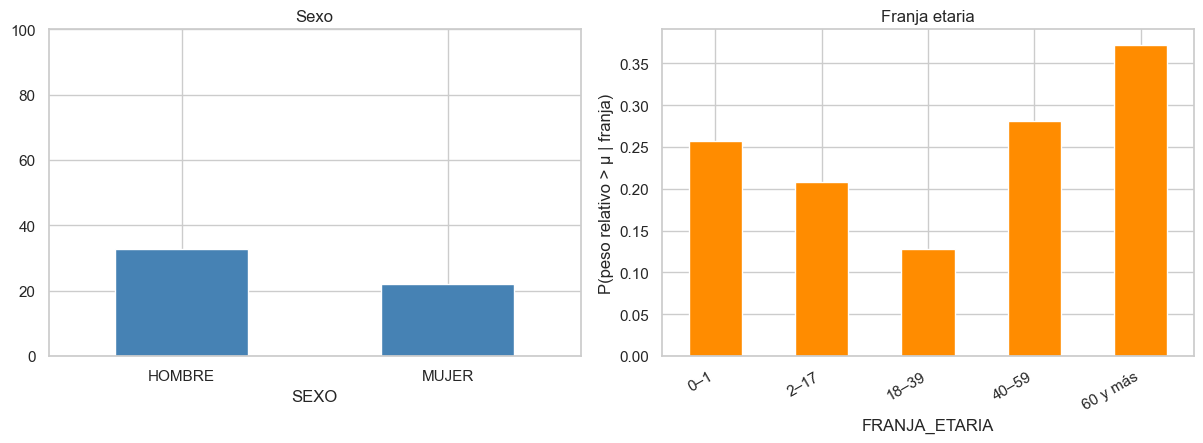


—— Regresión logística sobre submuestra balanceada (robusta a coste computacional) ——
n = 190,000 (95,000 VD=1 · 95,000 VD=0)
Intercept (log OR) = 0.267813; OR(intercepto) ≈ 1.3071
Interpretación coeficientes: exponencial de estimación punto (no intervalos Wald en esta corrida rápida).
Referencias: sexo MUJER; primera región y primera franja alfabéticamente después de agrupamiento.


,coef,OR
HOMBRE,0.458138,1.581127
EDAD_z,0.388861,1.475300
RG_Aysén,0.301874,1.352391
RG_Magallanes,0.292465,1.339726
RG_Metropolitana,0.220587,1.246808
RG_Valparaíso,0.187106,1.205756
RG_Los Ríos,0.114860,1.121716
RG_Biobío,0.092065,1.096436
RG_O'Higgins,0.070107,1.072623
RG_Maule,0.058826,1.060591


CSV: logistica_SOBRE_PROMEDIO_OR.csv


In [78]:
from IPython.display import display

from sklearn.linear_model import LogisticRegression

RNG_SEED_POS = 9_123

RNG_SEED_NEG = 9_124

RNG_SHUFFLE = 42

MAX_SIDE = 95_000  # máximo por lado en balanceo de la logística


def cramers_v(chi2_value: float, n: int, r: int, c: int) -> float:

    dim = min(r, c)

    return float(np.sqrt(chi2_value / max(n * (dim - 1), 1)))


# --- VD: pacientes con peso relativo MAYOR QUE el promedio muestral ---
mu_px = analisis["IR_29301_PESO"].astype(float).mean()


md_px = analisis["IR_29301_PESO"].astype(float).median()


work = analisis.copy()

work["SOBRE_PROMEDIO"] = work["IR_29301_PESO"].astype(float) > mu_px

work["_SENS_MAYOR_MEDIANA"] = work["IR_29301_PESO"].astype(float) > md_px


N_w = len(work)

n_above = int(work["SOBRE_PROMEDIO"].sum())

print(f"µ(IR_29301_PESO) sobre analisis = {mu_px:.6f}")

print(f"Mediana muestral IR_29301_PESO = {md_px:.6f}")

print(f"Casos con IR_29301_PESO > µ (SOBRE_PROMEDIO): {n_above:,} ({100 * n_above / N_w:.2f}%)")


ambos_med = ((work["SOBRE_PROMEDIO"]) & (work["_SENS_MAYOR_MEDIANA"])).sum()

solo_mu_sin_mediana = ((work["SOBRE_PROMEDIO"]) & (~work["_SENS_MAYOR_MEDIANA"])).sum()

print(

    f"\nRobustez: dentro de los >µ, {ambos_med:,} (>µ ∧ >median) vs {solo_mu_sin_mediana:,}"

    " con >µ pero ≤median (consistente con colas extremas).\n",

)


# Franjas sobre EDAD años: separar explícitamente 0–1 del resto de menores de 18.
bins_e = [-0.001, 1, 17, 39, 59, 200]

labels_age = ["0–1", "2–17", "18–39", "40–59", "60 y más"]

work["FRANJA_ETARIA"] = pd.cut(
    work["EDAD"].astype(float).clip(lower=0, upper=120),

    bins=bins_e,

    labels=labels_age,

)



metricas_lin = []

def chi2_mostrar(obs: pd.DataFrame, etiqueta: str) -> tuple[float, float, float]:
    tabla = obs.fillna(0).astype(np.int64)

    chi2_, p_, dof_, exp_ = stats.chi2_contingency(tabla, correction=False)

    v_ = cramers_v(chi2_, int(tabla.values.sum()), *tabla.shape)

    metricas_lin.append({"factor": etiqueta, "Chi2_pearson": chi2_, "gl": dof_, "pvalor": p_, "cramers_V": v_})

    print(f"\n--- {etiqueta} ---")

    display(tabla)

    pct_bajo5 = np.mean(exp_ < 5) * 100

    if pct_bajo5 > 5:

        print(f"¡Atención! {pct_bajo5:.1f}% esperados < 5; interpretación conservadora recomendada.")

    print(f"χ² Pearson = {chi2_:.4f}, gl = {dof_}, p = {p_:.4e}")

    print(f"V de Cramér = {v_:.6f}")

    return chi2_, p_, v_


def renom(br: bool) -> str:

    return "> µ (VD=1)" if br else "≤ µ"


# Sexo
sx = pd.crosstab(work["SEXO"], work["SOBRE_PROMEDIO"])

sx.columns = [renom(c) for c in sx.columns.astype(bool)]

chi2_mostrar(sx, "SOBRE_PROMEDIO × SEXO")

tasa_sexo = pd.DataFrame({"n_tot": sx.sum(axis=1)})


tasa_sexo["pct_sobre_med"] = 100 * sx["> µ (VD=1)"] / tasa_sexo["n_tot"]

display(tasa_sexo.round(4))


fe = work.dropna(subset=["FRANJA_ETARIA"]).copy()


ag = pd.crosstab(fe["FRANJA_ETARIA"], fe["SOBRE_PROMEDIO"])

ag.columns = [renom(c) for c in ag.columns.astype(bool)]

chi2_mostrar(ag.astype(int), "SOBRE_PROMEDIO × FRANJA_ETARIA")

pct_fila = ag.div(ag.sum(axis=1), axis=0)

print("\n¿En qué franja la probabilidad peso-relativo sobre µ es mayor? (% filas)")

display((100 * pct_fila).round(2))


rg = pd.crosstab(work["REGION"], work["SOBRE_PROMEDIO"])

rg.columns = [renom(c) for c in rg.columns.astype(bool)]

chi2_mostrar(rg, "SOBRE_PROMEDIO × REGION")


K_TOP = 40

freq_com = work["COMUNA"].value_counts(sort=True)

top_co = freq_com.iloc[:K_TOP].index.astype(str)

work["_COMUNA_GRP"] = work["COMUNA"].astype(str).where(work["COMUNA"].isin(top_co), "OTROS")

cm = pd.crosstab(work["_COMUNA_GRP"], work["SOBRE_PROMEDIO"])

cm.columns = [renom(c) for c in cm.columns.astype(bool)]

chi2_, p_cm, dof_cm, exp_cm = stats.chi2_contingency(cm, correction=False)


v_cm = cramers_v(chi2_, int(cm.sum().sum()), *cm.shape)

metricas_lin.append({"factor": f"COMUNA top{K_TOP}+OTROS", "Chi2_pearson": chi2_, "gl": dof_cm, "pvalor": p_cm, "cramers_V": v_cm})

print(f"\n--- SOBRE_PROMEDIO × COMUNA agrupada (top {K_TOP} + OTROS) ---")

display(cm.astype(int))

resid_mu = ((cm.iloc[:, 1].astype(float).values - exp_cm[:, 1]) / np.sqrt(np.clip(exp_cm[:, 1], 1e-12, np.inf))).round(5)

diag_com = pd.DataFrame(
    {
        "n_total_registros": cm.sum(axis=1),
        "n_sobre_med": cm.iloc[:, 1],
        "pct_filas_superan_mu": 100 * cm.iloc[:, 1] / cm.sum(axis=1),
        "Pearson_residuo_col_sobre_med": resid_mu,

    },

).sort_values("Pearson_residuo_col_sobre_med", ascending=False)



print("\nComunas agrupadas con mayor residuo estandarizado (columna >µ):")
display(diag_com.head(18))



pd.DataFrame(metricas_lin).to_csv("metricas_homogeneidad_SOBRE_PROMEDIO.csv", index=False, encoding="utf-8")


diag_com.to_csv("comunas_residual_SOBRE_PROMEDIO.csv", encoding="utf-8")


print("\nCSV guardados: metricas_homogeneidad_SOBRE_PROMEDIO.csv, comunas_residual_SOBRE_PROMEDIO.csv")



fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.6))



(tasa_sexo["pct_sobre_med"].rename("% > µ dentro del sexo")).plot(kind="bar", ax=axes[0], color="steelblue", rot=0)

axes[0].set_title("Sexo")

axes[0].set_ylim(0, max(100, tasa_sexo["pct_sobre_med"].max() * 1.1))



fe.groupby("FRANJA_ETARIA", observed=True)["SOBRE_PROMEDIO"].mean().reindex(labels_age).plot(
    kind="bar",
    ax=axes[1],
    color="darkorange",
)

axes[1].set_ylabel("P(peso relativo > µ | franja)")

axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha="right")


axes[1].set_title("Franja etaria")

plt.tight_layout()


plt.show()



n_take = min(MAX_SIDE, int(work["SOBRE_PROMEDIO"].sum()), int((~work["SOBRE_PROMEDIO"]).sum()))

pos_sm = work.loc[work["SOBRE_PROMEDIO"]].sample(n=n_take, random_state=RNG_SEED_POS)

neg_sm = work.loc[~work["SOBRE_PROMEDIO"]].sample(n=n_take, random_state=RNG_SEED_NEG)

sub_gl = pd.concat([pos_sm, neg_sm], axis=0).sample(frac=1.0, random_state=RNG_SHUFFLE)

sub_gl = sub_gl.dropna(subset=["FRANJA_ETARIA"])



mu_age = work["EDAD"].astype(float).mean()

sig_age = work["EDAD"].astype(float).std(ddof=0)



sex_dm = pd.get_dummies(sub_gl["SEXO"], dtype=float)


if "MUJER" in sex_dm.columns:
    sex_dm = sex_dm.drop(columns=["MUJER"])



rg_dm = pd.get_dummies(sub_gl["REGION"], prefix="RG", dtype=float)

rg_dm = rg_dm.drop(columns=[rg_dm.columns[0]]) if rg_dm.shape[1] > 1 else rg_dm




fr_dm = pd.get_dummies(sub_gl["FRANJA_ETARIA"].astype(str), prefix="FR", dtype=float)

fr_dm = fr_dm.drop(columns=[fr_dm.columns[0]]) if fr_dm.shape[1] > 1 else fr_dm




Xgl = pd.concat(
    [
        ((sub_gl["EDAD"].astype(float) - mu_age) / sig_age).rename("EDAD_z").to_frame(),
        sex_dm,
        rg_dm,
        fr_dm,
    ],
    axis=1,

).fillna(0.0)

ygl = sub_gl["SOBRE_PROMEDIO"].astype(np.int64)

clf = LogisticRegression(
    penalty="l2",
    C=10.0,
    solver="lbfgs",
    max_iter=1_600,
)

clf.fit(Xgl, ygl)


or_tbl = pd.DataFrame({"coef": clf.coef_[0], "OR": np.exp(clf.coef_[0])}, index=Xgl.columns).sort_values("OR", ascending=False)

print("\n—— Regresión logística sobre submuestra balanceada (robusta a coste computacional) ——")

print(f"n = {len(sub_gl):,} ({n_take:,} VD=1 · {n_take:,} VD=0)")

print(f"Intercept (log OR) = {clf.intercept_[0]:.6f}; OR(intercepto) ≈ {np.exp(clf.intercept_[0]):.4f}")

print("Interpretación coeficientes: exponencial de estimación punto (no intervalos Wald en esta corrida rápida).")

print("Referencias: sexo MUJER; primera región y primera franja alfabéticamente después de agrupamiento.")

display(or_tbl)



or_tbl.round(6).to_csv("logistica_SOBRE_PROMEDIO_OR.csv")

print("CSV: logistica_SOBRE_PROMEDIO_OR.csv")


## 5c. Combinaciones de **sexo**, **franja etaria con RN aparte** y **comuna** frente al peso GRD

Objetivo: ver **dónde son más altas las medianas de `IR_29301_PESO`** cuando se cruza socio-demografía y una franja donde **los recién nacidos van separados**.

- **`FRANJA_ED_DET`**: **recién nacidos** = registros con **`EDAD = 0`** (años según la base); después se usan **1–17**, **18–39**, **40–59**, **60 y más** con la misma variable `EDAD`.
- Comunas solo en **rankings con `n` mínimo**; inferencia rápida: **Kruskal–Wallis** por sexo (con **`n_min_kw`** por franja).




Distribución FRANJA_ED_DET (recién nacidos: EDAD=0 años):
FRANJA_ED_DET
RN (EDAD años = 0)     34197
1-17 años             137852
18-39 años            275165
40-59 años            211998
60 años o más         388803
Name: count, dtype: int64

Mediana peso GRD por SEXO × franja:


,SEXO,FRANJA_ED_DET,n,mediana,p75
0,HOMBRE,RN (EDAD años = 0),18861,0.5475,1.6030
1,HOMBRE,1-17 años,78011,0.6172,0.9628
2,HOMBRE,18-39 años,64524,0.7398,10.2010
3,HOMBRE,40-59 años,87824,0.8561,11.7180
4,HOMBRE,60 años o más,188329,0.8850,12.4160
5,MUJER,RN (EDAD años = 0),15336,0.5346,1.6030
6,MUJER,1-17 años,59841,0.6255,1.2040
7,MUJER,18-39 años,210641,0.5155,0.6915
8,MUJER,40-59 años,124174,0.7124,1.2490
9,MUJER,60 años o más,200474,0.8209,11.4720


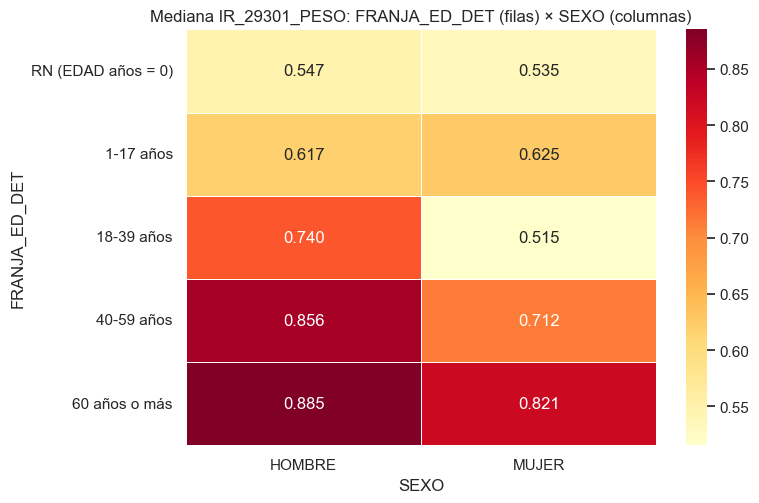


Kruskal–Wallis por FRANJA_ED_DET (celdas con n>=250 dentro de cada sexo):
  HOMBRE: H=21492.92, p=0.000e+00, grupos incluidos k=5
  MUJER: H=84440.68, p=0.000e+00, grupos incluidos k=5

Mayor MEDIANA de IR_29301_PESO entre comunas con n≥800 (top 22, lectura cualitativa):


,n,mediana
COMUNA,,
ANCUD,933,0.80370
RENGO,1356,0.79940
PUCHUNCAVÍ,957,0.79940
VALPARAISO,19910,0.79460
CASABLANCA,1683,0.79460
PEÑAFLOR,3460,0.79190
LAS CONDES,3605,0.78970
CON CON,1767,0.78930
VIÑA DEL MAR,16429,0.78760



Menores medianas dentro del mismo filtro de n:


,n,mediana
COMUNA,,
PUNITAQUI,805,0.5856
ALTO HOSPICIO,6163,0.6100
CHEPICA,959,0.6255
PICHILEMU,931,0.6255
OVALLE,8145,0.6255
MELIPILLA,10547,0.6255
LAMPA,4140,0.6255
MONTE PATRIA,2034,0.6255
DALCAHUE,981,0.6261



Archivos escritos: medianas_peso_sexo_FRANJA_ED_DET.csv, rank_comunas_mediana_peso_GRD_umbral_n.csv


In [79]:
from IPython.display import display

_FRANJA_ORDEN = (
    "RN (EDAD años = 0)",
    "1-17 años",
    "18-39 años",
    "40-59 años",
    "60 años o más",
)


def franja_ed_det(an: pd.DataFrame) -> pd.Series:
    ed = an["EDAD"].astype(float)
    out = pd.Series(pd.NA, index=an.index, dtype="string")
    ok = ed.notna()
    out.loc[ok & (ed == 0)] = _FRANJA_ORDEN[0]
    out.loc[ok & ed.between(1, 17)] = _FRANJA_ORDEN[1]
    out.loc[ok & ed.between(18, 39)] = _FRANJA_ORDEN[2]
    out.loc[ok & ed.between(40, 59)] = _FRANJA_ORDEN[3]
    out.loc[ok & (ed >= 60)] = _FRANJA_ORDEN[4]
    return out


analisis["FRANJA_ED_DET"] = franja_ed_det(analisis)

analisis["FRANJA_ED_DET"] = pd.Categorical(analisis["FRANJA_ED_DET"], categories=list(_FRANJA_ORDEN), ordered=True)

print("\nDistribución FRANJA_ED_DET (recién nacidos: EDAD=0 años):")
print(analisis["FRANJA_ED_DET"].value_counts(dropna=False).sort_index())

wk = analisis.dropna(subset=["FRANJA_ED_DET"]).copy()

_gb = ["SEXO", "FRANJA_ED_DET"]
_gserie = wk.groupby(_gb, observed=False)["IR_29301_PESO"]

tab_sf = _gserie.agg(n="count", mediana="median").join(_gserie.quantile(0.75).rename("p75"))

print("\nMediana peso GRD por SEXO × franja:")
display(tab_sf.reset_index())

heat = tab_sf["mediana"].unstack(level=0).reindex(list(_FRANJA_ORDEN))

fig_h, ax_h = plt.subplots(figsize=(8, 5.2))
sns.heatmap(heat, annot=True, fmt=".3f", cmap="YlOrRd", ax=ax_h, linewidths=0.5)
ax_h.set_title("Mediana IR_29301_PESO: FRANJA_ED_DET (filas) × SEXO (columnas)")
plt.tight_layout()
plt.show()

tab_sf.reset_index().to_csv("medianas_peso_sexo_FRANJA_ED_DET.csv", index=False, encoding="utf-8")

n_min_kw = 250
print("\nKruskal–Wallis por FRANJA_ED_DET (celdas con n>=%d dentro de cada sexo):" % n_min_kw)
for sex in sorted(wk["SEXO"].unique()):
    sub = wk.loc[wk["SEXO"] == sex]
    grp = []
    for f in _FRANJA_ORDEN:
        valores = sub.loc[sub["FRANJA_ED_DET"] == f, "IR_29301_PESO"].astype(float).dropna().to_numpy()
        if valores.size >= n_min_kw:
            grp.append(valores)
    if len(grp) < 2:
        print("  %s: menos de dos estratos válidos después del umbral" % sex)
        continue
    h_kw, p_kw = stats.kruskal(*grp)
    print("  %s: H=%.2f, p=%.3e, grupos incluidos k=%d" % (sex, h_kw, p_kw, len(grp)))

n_min_com = 800

com_med = (
    analisis.groupby("COMUNA", observed=False)["IR_29301_PESO"].agg(
        n="count",
        mediana="median",
    )
)
com_med = com_med.loc[com_med["n"] >= n_min_com].sort_values("mediana", ascending=False)

print("\nMayor MEDIANA de IR_29301_PESO entre comunas con n≥%d (top 22, lectura cualitativa):" % n_min_com)
display(com_med.head(22))

print("\nMenores medianas dentro del mismo filtro de n:")
display(com_med.tail(14).sort_values("mediana"))

com_med.head(60).reset_index().to_csv("rank_comunas_mediana_peso_GRD_umbral_n.csv", index=False, encoding="utf-8")

print("\nArchivos escritos: medianas_peso_sexo_FRANJA_ED_DET.csv, rank_comunas_mediana_peso_GRD_umbral_n.csv")


## 5d. Perfil **sexo × franja etaria** entre pacientes con **alto costo** (`ALTO_COSTO`)

**Población:** episodios en `analisis` con **`ALTO_COSTO`** (`COSTO_APROXIMADO` ≥ P75 muestral), alineado al glosario.

**Franjas exclusivas desde `EDAD` (años):**

| Etiqueta | Criterio en la base |
|----------|---------------------|
| **0-1 años** | `EDAD ≤ 1` (incluye recién nacidos con `EDAD = 0` y año 1). |
| **1-18 años** | `2 ≤ EDAD ≤ 17` (menores de 18 sin duplicar 0–1). |
| **18-39 años** | `18 ≤ EDAD ≤ 39`. |
| **40-59 años** | `40 ≤ EDAD ≤ 59`. |
| **60 o más** | `EDAD ≥ 60`. |

**Salidas:** tabla de **n** y **% dentro de alto costo**, **tasas de alto costo por celda** respecto del total de esa celda, **$\chi^2$** sobre el cruce sexo–franja dentro de alto costo, histogramas de **`IR_29301_PESO`** facetados por sexo y franja (misma escala horizontal recortada al **P99** global del peso para lectura).

Lectura: la **combinación más frecuente** (mayor **n**) indica qué perfil “más se repite” entre quienes ya están en alto costo; contrastar con la **mediana** del peso por celda conecta con la hipótesis de peso GRD alto (p. ej. hombres 60+).


— Alto costo (ALTO_COSTO) × sexo × franja etaria —
Población con EDAD válida y clasificada: 1,048,015
Episodios ALTO_COSTO en esa población: 262,647 (25.06%)

Ranking de perfiles por n (entre quienes tienen alto costo):


,SEXO,FRANJA_ETARIA_5,n_alto_costo,n_celda_total,mediana_peso_alto_costo,mediana_peso_todos,pct_dentro_alto_costo,tasa_alto_costo_pct_celda
4,HOMBRE,60 o más,70102,188329.0,14.807,0.8850,26.690577,37.223157
9,MUJER,60 o más,65936,200474.0,14.477,0.8209,25.104418,32.890051
3,HOMBRE,40-59 años,28779,87824.0,14.829,0.8561,10.957292,32.768947
8,MUJER,40-59 años,27687,124174.0,13.157,0.7124,10.541525,22.296938
7,MUJER,18-39 años,16555,210641.0,12.665,0.5155,6.303137,7.859344
2,HOMBRE,18-39 años,16425,64524.0,14.411,0.7398,6.253641,25.455644
1,HOMBRE,1-18 años,13176,68940.0,11.823,0.6116,5.016619,19.112272
6,MUJER,1-18 años,11254,52909.0,11.817,0.6253,4.284839,21.270483
0,HOMBRE,0-1 años,6987,27932.0,15.477,0.5821,2.660225,25.014320
5,MUJER,0-1 años,5746,22268.0,17.658,0.5821,2.187727,25.803844



Perfil más frecuente en ALTO_COSTO: HOMBRE × 60 o más — n = 70,102 (26.69% del subconjunto alto costo).

χ² (SEXO × franja | ALTO_COSTO): estadístico=159.81, gl=4, p=1.6066e-33

CSV: perfil_alto_costo_sexo_franja_5.csv


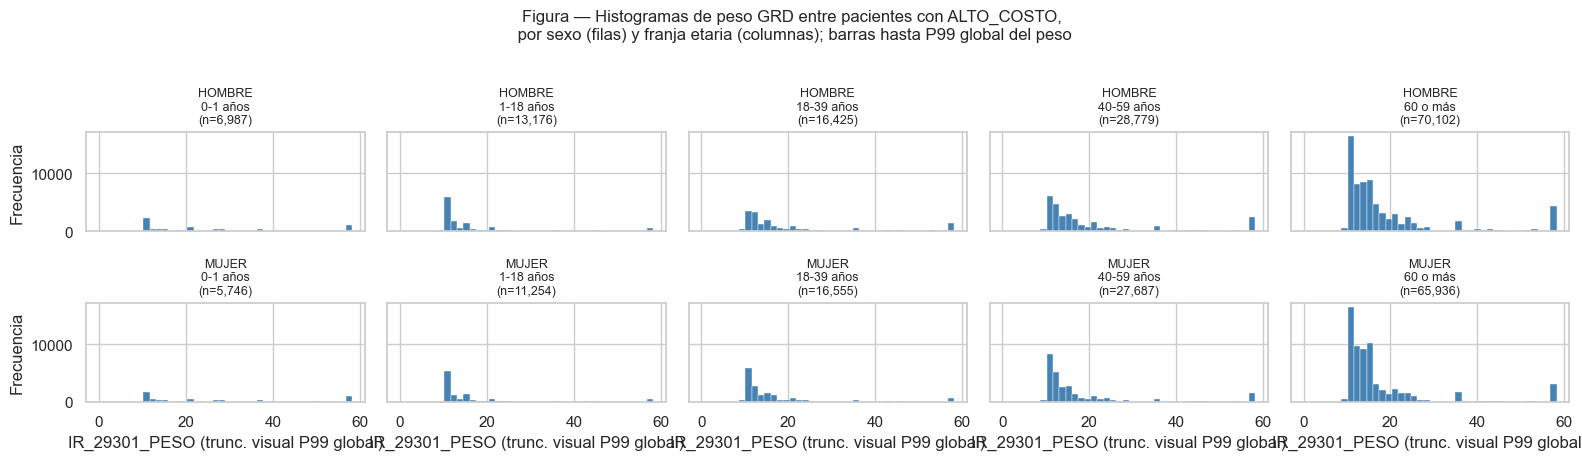

In [80]:
from IPython.display import display

# Franjas solicitadas (exclusivas; "1-18" = 2..17 para no solapar con 0-1).
_FR_AC_ORDEN = (
    "0-1 años",
    "1-18 años",
    "18-39 años",
    "40-59 años",
    "60 o más",
)


def franja_etaria_5(s_edad: pd.Series) -> pd.Series:
    e = pd.to_numeric(s_edad, errors="coerce")
    labels = pd.Series(pd.NA, index=s_edad.index, dtype="object")
    labels.loc[e <= 1] = _FR_AC_ORDEN[0]
    labels.loc[(e >= 2) & (e <= 17)] = _FR_AC_ORDEN[1]
    labels.loc[(e >= 18) & (e <= 39)] = _FR_AC_ORDEN[2]
    labels.loc[(e >= 40) & (e <= 59)] = _FR_AC_ORDEN[3]
    labels.loc[e >= 60] = _FR_AC_ORDEN[4]
    return labels.rename("FRANJA_ETARIA_5")


base_ac = analisis.dropna(subset=["EDAD", "SEXO", "IR_29301_PESO"]).copy()
base_ac["FRANJA_ETARIA_5"] = franja_etaria_5(base_ac["EDAD"])
mask_franja = base_ac["FRANJA_ETARIA_5"].notna()
base_ac = base_ac.loc[mask_franja].copy()
base_ac["FRANJA_ETARIA_5"] = pd.Categorical(
    base_ac["FRANJA_ETARIA_5"], categories=list(_FR_AC_ORDEN), ordered=True
)

ac = base_ac.loc[base_ac["ALTO_COSTO"]].copy()
n_ac = len(ac)
n_tot = len(base_ac)
print("— Alto costo (ALTO_COSTO) × sexo × franja etaria —")
print(f"Población con EDAD válida y clasificada: {n_tot:,}")
print(f"Episodios ALTO_COSTO en esa población: {n_ac:,} ({100 * n_ac / n_tot:.2f}%)\n")

# Grilla sexo × franja (órdenes fijos para tablas, CSV y χ²)
sexos_ord = [s for s in ("HOMBRE", "MUJER") if s in set(base_ac["SEXO"].astype(str))]
if not sexos_ord:
    sexos_ord = sorted(base_ac["SEXO"].astype(str).unique())

grid_ix = pd.MultiIndex.from_product(
    [sexos_ord, list(_FR_AC_ORDEN)], names=["SEXO", "FRANJA_ETARIA_5"]
)

n_ac_celda = (
    ac.groupby(["SEXO", "FRANJA_ETARIA_5"], observed=False)
    .size()
    .reindex(grid_ix)
    .fillna(0)
    .astype(np.int64)
)
n_tot_celda = base_ac.groupby(["SEXO", "FRANJA_ETARIA_5"], observed=False).size().reindex(grid_ix)
med_ac = (
    ac.groupby(["SEXO", "FRANJA_ETARIA_5"], observed=False)["IR_29301_PESO"]
    .median()
    .reindex(grid_ix)
)
med_all = (
    base_ac.groupby(["SEXO", "FRANJA_ETARIA_5"], observed=False)["IR_29301_PESO"]
    .median()
    .reindex(grid_ix)
)

perfil_tab = pd.DataFrame(
    {
        "SEXO": grid_ix.get_level_values(0),
        "FRANJA_ETARIA_5": grid_ix.get_level_values(1),
        "n_alto_costo": n_ac_celda.values,
        "n_celda_total": n_tot_celda.values.astype(float),
        "mediana_peso_alto_costo": med_ac.values,
        "mediana_peso_todos": med_all.values,
    }
)
perfil_tab["pct_dentro_alto_costo"] = np.where(n_ac > 0, 100 * perfil_tab["n_alto_costo"] / n_ac, 0.0)
perfil_tab["tasa_alto_costo_pct_celda"] = 100 * perfil_tab["n_alto_costo"] / perfil_tab["n_celda_total"]

perfil_rank = perfil_tab.sort_values("n_alto_costo", ascending=False)

print("Ranking de perfiles por n (entre quienes tienen alto costo):")
display(perfil_rank.round(6))

top = perfil_rank.iloc[0]
print(
    "\nPerfil más frecuente en ALTO_COSTO: "
    f"{top['SEXO']} × {top['FRANJA_ETARIA_5']} — "
    f"n = {int(top['n_alto_costo']):,} ({top['pct_dentro_alto_costo']:.2f}% del subconjunto alto costo)."
)

# Chi-cuadrado: asociación SEXO × franja dentro de ALTO_COSTO
tab = pd.crosstab(ac["SEXO"], ac["FRANJA_ETARIA_5"]).reindex(
    index=sexos_ord, columns=list(_FR_AC_ORDEN)
)
tab = tab.fillna(0)
chi2, p_chi2, dof, exp = stats.chi2_contingency(tab.to_numpy())
print(f"\nχ² (SEXO × franja | ALTO_COSTO): estadístico={chi2:.2f}, gl={dof}, p={p_chi2:.4e}")

perfil_tab.to_csv("perfil_alto_costo_sexo_franja_5.csv", index=False, encoding="utf-8")
print("\nCSV: perfil_alto_costo_sexo_franja_5.csv")

# --- Histogramas: IR_29301_PESO por sexo (filas) y franja (columnas), solo ALTO_COSTO ---
p99_peso_global = float(base_ac["IR_29301_PESO"].quantile(0.99))
fig, axes = plt.subplots(len(sexos_ord), len(_FR_AC_ORDEN), figsize=(16, 4.5), sharex=True, sharey="row")
if len(sexos_ord) == 1:
    axes = np.array([axes])

for ri, sx in enumerate(sexos_ord):
    for ci, fr in enumerate(_FR_AC_ORDEN):
        ax = axes[ri, ci]
        datos = ac.loc[(ac["SEXO"] == sx) & (ac["FRANJA_ETARIA_5"] == fr), "IR_29301_PESO"].astype(float)
        if len(datos) > 0:
            ax.hist(
                datos.clip(upper=p99_peso_global),
                bins=40,
                range=(0, p99_peso_global),
                color="steelblue",
                edgecolor="white",
                linewidth=0.3,
            )
        ax.set_title(f"{sx}\n{fr}\n(n={len(datos):,})", fontsize=9)
        if ri == len(sexos_ord) - 1:
            ax.set_xlabel("IR_29301_PESO (trunc. visual P99 global)")
        if ci == 0:
            ax.set_ylabel("Frecuencia")

fig.suptitle(
    "Figura — Histogramas de peso GRD entre pacientes con ALTO_COSTO,\n por sexo (filas) y franja etaria (columnas); barras hasta P99 global del peso",
    fontsize=12,
    y=1.02,
)
plt.tight_layout()
plt.show()


## 6. Test de hipótesis (único contraste omnibus sobre **gasto acumulado por persona**)

**Unidad analítica:** cada **`ID_BENEFICIARIO`**. Se suma **`COSTO_APROXIMADO`** (= `IR_29301_PESO × 400_000`) en **todas sus atenciones** del `analisis` (egresos reiterados y episodios con peso alto entran igual en la suma). El perfil territorial se resume con **moda de comuna** dentro del historial; la **franja etaria** se asigna con la **mayor edad observada** en sus episodios (misma lógica de cortes que en §5b: **0–1**, **2–17**, **18–39**, **40–59**, **60 y más**).

**H₀:** las distribuciones del **gasto total proxy por beneficiario** son **iguales** entre los **diez perfiles** `SEXO × FRANJA_ETARIA`.

**H₁:** al menos un perfil presenta distribución diferente (**mayor gasto típico o cola más pesada**) en ese acumulado.

**Procedimiento (único test):** **Kruskal–Wallis** sobre los mismos datos agregados (sin submuestreo). Es adecuado cuando el gasto tiene colas muy asimet y varios grupos. **α = 0,05**.

**Complemento descriptivo (no son tests adicionales):** tabla de **`gasto_total`**, **`n_benef`** y episodios totales por **sexo × franja × comuna** exportada a CSV; concentración tipo “los *x*% de beneficiarios con más gasto acumulan *y*% del gasto total”; y la fracción **`gasto_max_ep / gasto_total`** para ver si el gasto altísimo viene sobre todo de **un solo egreso** o de **varias atenciones**.

**Nota:** no se cruza comuna en el Kruskal–Wallis para evitar miles de celdas ralas; la lectura territorial queda en la tabla y en el CSV.

In [81]:
from IPython.display import display

alpha = 0.05

_FR_KW = ("0–1", "2–17", "18–39", "40–59", "60 y más")


def _franja_ed_kw(e: pd.Series) -> pd.Series:
    e = pd.to_numeric(e, errors="coerce")
    lab = pd.Series(pd.NA, index=e.index, dtype="object")
    lab.loc[e <= 1] = _FR_KW[0]
    lab.loc[(e >= 2) & (e <= 17)] = _FR_KW[1]
    lab.loc[(e >= 18) & (e <= 39)] = _FR_KW[2]
    lab.loc[(e >= 40) & (e <= 59)] = _FR_KW[3]
    lab.loc[e >= 60] = _FR_KW[4]
    return lab


def _mode_first(s: pd.Series):
    s = s.dropna()
    if s.empty:
        return np.nan
    m = s.mode()
    return m.iloc[0] if len(m) else s.iloc[0]


bb = analisis.dropna(subset=["ID_BENEFICIARIO", "COSTO_APROXIMADO", "SEXO", "COMUNA", "EDAD"]).copy()
bb["ID_BENEFICIARIO"] = bb["ID_BENEFICIARIO"].astype(str).str.strip()

ben = (
    bb.groupby("ID_BENEFICIARIO", sort=False)
    .agg(
        gasto_total=("COSTO_APROXIMADO", "sum"),
        n_episodios=("COSTO_APROXIMADO", "size"),
        gasto_max_ep=("COSTO_APROXIMADO", "max"),
        SEXO=("SEXO", _mode_first),
        COMUNA=("COMUNA", lambda s: _mode_first(s.astype(str).str.strip())),
        edad_max=("EDAD", "max"),
    )
    .reset_index()
)
ben["FRANJA_ETARIA"] = pd.Categorical(
    _franja_ed_kw(ben["edad_max"]), categories=list(_FR_KW), ordered=True
)
ben = ben.dropna(subset=["SEXO", "COMUNA"])
ben = ben.loc[ben["FRANJA_ETARIA"].notna()].copy()
ben["prop_max_ep_sobre_total"] = ben["gasto_max_ep"] / ben["gasto_total"].replace(0, np.nan)

ben["perfil_sexo_franja"] = (
    ben["SEXO"].astype(str) + " × " + ben["FRANJA_ETARIA"].astype(str)
)

print(
    f"Agregación beneficiario: {len(ben):,} personas distintas; "
    f"{len(bb):,} egresos/episodios usados en la suma (toda la muestra `analisis` con campos válidos)."
)
print(f"Gasto total cohorte (suma proxy) = {ben['gasto_total'].sum():,.0f} pesos\n")

grupos_kw = []
etiq_kw = []
for perf in sorted(ben["perfil_sexo_franja"].unique()):
    arr = ben.loc[ben["perfil_sexo_franja"] == perf, "gasto_total"].astype(float).to_numpy()
    grupos_kw.append(arr)
    etiq_kw.append(perf)

h_kw, p_kw = stats.kruskal(*grupos_kw)

print("Único test — Kruskal–Wallis: gasto_total_beneficiario ~ perfil (SEXO × FRANJA_ETARIA)")
print(f"  H (estadístico) = {h_kw:.4f}")
print(f"  p-valor         = {p_kw:.4e}")
print(f"  k grupos        = {len(grupos_kw)}")

if p_kw < alpha:
    print(
        f"\nDecisión (α={alpha}): se rechaza H₀; hay evidencia de que al menos un perfil "
        "(sexo × edad) difiere en la **posición** típica del gasto acumulado por persona en la proxy usada."
    )
else:
    print(
        f"\nDecisión (α={alpha}): no se rechaza H₀ con este contraste omnibus "
        "sobre las distribuciones del gasto acumulado por perfil."
    )

resumen_pf = (
    ben.groupby(["SEXO", "FRANJA_ETARIA"], observed=False)
    .agg(
        n_benef=("gasto_total", "size"),
        gasto_celda_total=("gasto_total", "sum"),
        mediana_gasto_benef=("gasto_total", "median"),
        media_gasto_benef=("gasto_total", "mean"),
        episodios_totales=("n_episodios", "sum"),
    )
    .reset_index()
    .sort_values("mediana_gasto_benef", ascending=False)
)

print("\nPerfiles Sexo × edad (beneficiarios) — ordenados por mediana de gasto acumulado:")
display(resumen_pf.round(2))

top_det = resumen_pf.iloc[0]
print(
    f"\nMayor mediana de gasto acumulado (perfil Sexo×edad): {top_det['SEXO']} × {top_det['FRANJA_ETARIA']} "
    f"(mediana = {top_det['mediana_gasto_benef']:,.0f} pesos; n = {int(top_det['n_benef']):,} beneficiarios)."
)

ben_ord = ben.sort_values("gasto_total", ascending=False).reset_index(drop=True)
G_tot = float(ben["gasto_total"].sum())
N_b = len(ben)
filas_conc = []
for frac in [0.01, 0.05, 0.10, 0.20]:
    k = max(1, int(np.ceil(frac * N_b)))
    pct_gasto = 100.0 * ben_ord.loc[: k - 1, "gasto_total"].sum() / G_tot
    filas_conc.append(
        {
            "pct_benef_mejor_colocados": 100 * frac,
            "pct_gasto_acumulado_muestra": round(pct_gasto, 2),
        }
    )
conc_df = pd.DataFrame(filas_conc)
print(
    "\nConcentración (beneficiarios ordenados por gasto total descendente): "
    'fila = "mejor" fracción de la cola con más gasto acumulado.'
)
display(conc_df)

print(
    "¿Un solo egreso domina el gasto del beneficiario? Distribución de "
    "gasto_max_ep / gasto_total (1 ⇒ todo en una atención):"
)
display(ben["prop_max_ep_sobre_total"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99]).round(4))

celda_sfc = (
    ben.groupby(["SEXO", "FRANJA_ETARIA", "COMUNA"], observed=False)
    .agg(
        n_benef=("gasto_total", "size"),
        gasto_total=("gasto_total", "sum"),
        n_episodios_totales=("n_episodios", "sum"),
        mediana_gasto_benef=("gasto_total", "median"),
        max_gasto_un_ep=("gasto_max_ep", "max"),
    )
    .reset_index()
    .sort_values("gasto_total", ascending=False)
)

print("Top 35 celdas (sexo × franja × comuna) por gasto total cohorte (todas las filas → CSV):")
display(celda_sfc.head(35).round(2))

celda_sfc.to_csv("gasto_total_sexo_franja_comuna_beneficiarios.csv", index=False, encoding="utf-8")
conc_df.to_csv("concentracion_gasto_beneficiarios.csv", index=False, encoding="utf-8")
resumen_pf.to_csv("gasto_resumen_sexo_franja_beneficiarios.csv", index=False, encoding="utf-8")
print(
    "\nCSV: gasto_total_sexo_franja_comuna_beneficiarios.csv; "
    "concentracion_gasto_beneficiarios.csv; gasto_resumen_sexo_franja_beneficiarios.csv"
)


Agregación beneficiario: 823,822 personas distintas; 1,048,015 egresos/episodios usados en la suma (toda la muestra `analisis` con campos válidos).
Gasto total cohorte (suma proxy) = 2,333,623,608,920 pesos

Único test — Kruskal–Wallis: gasto_total_beneficiario ~ perfil (SEXO × FRANJA_ETARIA)
  H (estadístico) = 115115.2392
  p-valor         = 0.0000e+00
  k grupos        = 10

Decisión (α=0.05): se rechaza H₀; hay evidencia de que al menos un perfil (sexo × edad) difiere en la **posición** típica del gasto acumulado por persona en la proxy usada.

Perfiles Sexo × edad (beneficiarios) — ordenados por mediana de gasto acumulado:


,SEXO,FRANJA_ETARIA,n_benef,gasto_celda_total,mediana_gasto_benef,media_gasto_benef,episodios_totales
4,HOMBRE,60 y más,138817,6.171199e+11,606000.0,4445564.11,189700
9,MUJER,60 y más,151008,5.383764e+11,384440.0,3565217.69,200320
3,HOMBRE,40–59,68586,2.738243e+11,367400.0,3992422.01,87806
2,HOMBRE,18–39,53835,1.592279e+11,328360.0,2957702.48,64599
8,MUJER,40–59,100239,2.380315e+11,301240.0,2374639.68,123986
6,MUJER,2–17,41829,8.793443e+10,264800.0,2102236.09,52859
0,HOMBRE,0–1,21623,8.289398e+10,262080.0,3833602.21,27544
1,HOMBRE,2–17,56854,1.048329e+11,250120.0,1843895.81,68962
5,MUJER,0–1,17587,7.157801e+10,246880.0,4069938.51,21867
7,MUJER,18–39,173444,1.598044e+11,209080.0,921360.16,210372



Mayor mediana de gasto acumulado (perfil Sexo×edad): HOMBRE × 60 y más (mediana = 606,000 pesos; n = 138,817 beneficiarios).

Concentración (beneficiarios ordenados por gasto total descendente): fila = "mejor" fracción de la cola con más gasto acumulado.


,pct_benef_mejor_colocados,pct_gasto_acumulado_muestra
0,1.0,15.97
1,5.0,42.57
2,10.0,59.01
3,20.0,79.67


¿Un solo egreso domina el gasto del beneficiario? Distribución de gasto_max_ep / gasto_total (1 ⇒ todo en una atención):


count    822654.0000
mean          0.9362
std           0.1601
min           0.0075
25%           1.0000
50%           1.0000
75%           1.0000
90%           1.0000
99%           1.0000
max           1.0000
Name: prop_max_ep_sobre_total, dtype: float64

Top 35 celdas (sexo × franja × comuna) por gasto total cohorte (todas las filas → CSV):


,SEXO,FRANJA_ETARIA,COMUNA,n_benef,gasto_total,n_episodios_totales,mediana_gasto_benef,max_gasto_un_ep
1603,HOMBRE,60 y más,PUENTE ALTO,4663,2.422164e+10,6584,1201240.0,68565600.0
3318,MUJER,60 y más,PUENTE ALTO,5827,2.269704e+10,8297,460680.0,46818000.0
1534,HOMBRE,60 y más,MAIPU,2943,1.708056e+10,3928,4298400.0,46818000.0
1492,HOMBRE,60 y más,LA FLORIDA,2944,1.502351e+10,4039,1044440.0,46818000.0
3207,MUJER,60 y más,LA FLORIDA,3745,1.502013e+10,4981,499600.0,46818000.0
1699,HOMBRE,60 y más,VALPARAISO,2752,1.463831e+10,4222,4033600.0,46818000.0
3249,MUJER,60 y más,MAIPU,3343,1.349603e+10,4233,726920.0,46818000.0
3414,MUJER,60 y más,VALPARAISO,3082,1.267413e+10,4447,702780.0,46818000.0
1529,HOMBRE,60 y más,LOS ÁNGELES,2477,1.187483e+10,3266,4050400.0,46818000.0
1677,HOMBRE,60 y más,SANTIAGO,1681,1.187018e+10,3357,4296400.0,46818000.0



CSV: gasto_total_sexo_franja_comuna_beneficiarios.csv; concentracion_gasto_beneficiarios.csv; gasto_resumen_sexo_franja_beneficiarios.csv


**Interpretación breve:** un p-valor bajo rechaza igualdad **entre perfiles Sexo × franja** en el **orden relativo típico** del gasto acumulado por persona y apunta a heterogeneidad de perfiles financieros ante el proxy usado en el proyecto. Para **¿quién pesa más dentro de ese mapa?,** ordenar las filas por **mediana** o **`gasto_total`** (CSV). La concentración muestra cuántos pocos usuarios cargan gran parte del gasto observado sin distinguir causa clínica. La proporción episodio-máximo / total cercana a 1 para muchos sugiere **un egreso muy caro dominante**, valores bajitos repartidos indican más **persistencia multisalida**.

## 7. Regresión lineal múltiple (MCO)

**Objetivo:** estimar asociación de `IR_29301_PESO` con edad, días de estadía, sexo, región y severidad (variables explicativas acordes al informe y a la pregunta 1).

**Especificación:** matriz diseño con intercepto, codificación indicadora (drop primer nivel en cada categórica).

In [82]:
def ols_mco_tabla(y: np.ndarray, X: np.ndarray, nombres: list):
    """MCO con inferencia clásica; X debe incluir columna de unos."""
    n, p = X.shape
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    resid = y - X @ beta
    rss = float((resid ** 2).sum())
    tss = float(((y - y.mean()) ** 2).sum())
    r2 = 1.0 - rss / tss if tss > 0 else np.nan
    r2_adj = 1.0 - (rss / (n - p)) / (tss / (n - 1)) if tss > 0 else np.nan
    sigma2 = rss / (n - p)
    XtX_inv = np.linalg.inv(X.T @ X)
    se = np.sqrt(np.clip(np.diag(XtX_inv) * sigma2, 0, np.inf))
    with np.errstate(divide="ignore", invalid="ignore"):
        t_stat = beta / se
    df_res = n - p
    p_vals = 2 * (1 - stats.t.cdf(np.abs(t_stat), df_res))
    # F global (modelo vs solo intercepto)
    ess = tss - rss
    df_m = p - 1
    f_glob = (ess / df_m) / (rss / df_res) if df_m > 0 and rss > 0 else np.nan
    p_glob = 1 - stats.f.cdf(f_glob, df_m, df_res) if np.isfinite(f_glob) else np.nan
    tabla = pd.DataFrame(
        {"coef": beta, "err.est": se, "t": t_stat, "p>|t|": p_vals},
        index=nombres,
    )
    return tabla, r2, r2_adj, f_glob, p_glob


reg_df = analisis.dropna(
    subset=["IR_29301_PESO", "EDAD", "DIAS_ESTADIA", "SEXO", "REGION", "IR_29301_SEVERIDAD"]
).copy()

_sev_cats = sorted(reg_df["IR_29301_SEVERIDAD"].unique())
reg_df["IR_29301_SEVERIDAD"] = pd.Categorical(
    reg_df["IR_29301_SEVERIDAD"], categories=_sev_cats, ordered=True
)

y = reg_df["IR_29301_PESO"].to_numpy(dtype=float)
X_num = reg_df[["EDAD", "DIAS_ESTADIA"]].to_numpy(dtype=float)

def dummies_drop_first(series: pd.Series):
    u = pd.Categorical(series)
    codes = pd.get_dummies(pd.Series(u, index=series.index), drop_first=True)
    return codes

Xd_sexo = dummies_drop_first(reg_df["SEXO"]).to_numpy(dtype=float)
Xd_reg = dummies_drop_first(reg_df["REGION"]).to_numpy(dtype=float)
Xd_sev = dummies_drop_first(reg_df["IR_29301_SEVERIDAD"]).to_numpy(dtype=float)

const = np.ones((len(y), 1))
X = np.hstack([const, X_num, Xd_sexo, Xd_reg, Xd_sev])

n_sexo = dummies_drop_first(reg_df["SEXO"]).columns.tolist()
n_reg = dummies_drop_first(reg_df["REGION"]).columns.tolist()
n_sev = dummies_drop_first(reg_df["IR_29301_SEVERIDAD"]).columns.tolist()
names = (
    ["const"]
    + ["EDAD", "DIAS_ESTADIA"]
    + [f"SEXO[{s}]" for s in n_sexo]
    + [f"REGION[{r}]" for r in n_reg]
    + [f"SEVERIDAD[{s}]" for s in n_sev]
)

tabla, r2, r2_adj, f_glob, p_glob = ols_mco_tabla(y, X, names)
print(f"N observaciones regresión: {len(y):,}")
print(f"R² = {r2:.4f}   R² ajustado = {r2_adj:.4f}")
print(f"F modelo = {f_glob:.4f}   p-valor (F) = {p_glob:.4e}")
display(tabla.round(6))

# Coeficientes de interés para interpretación en el informe
for v in ["EDAD", "DIAS_ESTADIA"] + [f"SEXO[{s}]" for s in n_sexo][:2] + [f"SEVERIDAD[{s}]" for s in n_sev][:2]:
    if v in tabla.index:
        r = tabla.loc[v]
        print(
            f"{v}: coef = {r['coef']:.6f}, p = {r['p>|t|']:.4e}"
        )

N observaciones regresión: 1,048,015
R² = 0.3201   R² ajustado = 0.3200
F modelo = 23490.2918   p-valor (F) = 0.0000e+00


,coef,err.est,t,p>|t|
const,0.363268,0.062539,5.808649,0.000000
EDAD,0.021726,0.000390,55.735614,0.000000
DIAS_ESTADIA,0.331134,0.000853,388.408737,0.000000
SEXO[MUJER],-1.122548,0.019703,-56.973425,0.000000
REGION[Arica y Parinacota],0.378788,0.088917,4.260005,0.000020
REGION[Atacama],-0.183986,0.087324,-2.106945,0.035123
REGION[Aysén],0.798349,0.112172,7.117168,0.000000
REGION[Biobío],0.120784,0.061795,1.954590,0.050632
REGION[Coquimbo],0.321997,0.070115,4.592402,0.000004
REGION[La Araucanía],-0.065989,0.064958,-1.015866,0.309694


EDAD: coef = 0.021726, p = 0.0000e+00
DIAS_ESTADIA: coef = 0.331134, p = 0.0000e+00
SEXO[MUJER]: coef = -1.122548, p = 0.0000e+00
SEVERIDAD[1]: coef = 0.119825, p = 1.8686e-05
SEVERIDAD[2]: coef = 2.106219, p = 0.0000e+00


**Interpretación aplicada (ejemplos para el informe):**

- **EDAD / DIAS_ESTADIA:** el signo del coeficiente indica si, manteniendo fijas las categorías del modelo, un año más o un día más se asocia con mayor o menor peso relativo **en promedio**.
- **SEXO[·]:** diferencias respecto al sexo de referencia (categoría omitida).
- **SEVERIDAD[·]:** diferencias de peso respecto al nivel de severidad de referencia; se interpreta como asociación episódica paralela al enfoque por **gasto acumulado por persona** del §6.

**Limitaciones:** relación probablemente no lineal; heterocedasticidad; $R^2$ no espera ser alto porque el peso tiene componente aleatorio y grupos GRD no están todos modelados con dummies finas.

## 8. Conclusiones preliminares y próximos pasos

1. **Pregunta 1 (descriptiva):** el bloque del subgrupo `SUBGRUPO_ALTO_PE_CO` entrega distribución de edad, sexo y comunas más frecuentes entre quienes tienen peso > 1 y costo proxy en el cuarto superior.
2. **Peso relativo sobre el promedio muestral** (`SOBRE_PROMEDIO`, sección **5b**): queda declarada una **VD** y **VI** cualitativas; los tabulares $\chi^2$, el **V de Cramér**, los CSV `metricas_homogeneidad_SOBRE_PROMEDIO.csv`, `comunas_residual_SOBRE_PROMEDIO.csv` y los **OR logísticos** (`logistica_SOBRE_PROMEDIO_OR.csv`) materializan el perfil y la magnitud ante $N \gg 10^5$.
3. **Combinaciones sexo–edad (RN separado)–comuna y peso GRD** (**5c**, `FRANJA_ED_DET`, `medianas_peso_sexo_FRANJA_ED_DET.csv`, `rank_comunas_mediana_peso_GRD_umbral_n.csv`; Kruskal–Wallis por sexo ante $N$ masivo como guía rápida, no efecto causal).
4. **Alto costo y perfil sociodemográfico** (**5d**, `ALTO_COSTO`, franjas 0–1 / 1–18 / 18–39 / 40–59 / 60+ y `perfil_alto_costo_sexo_franja_5.csv`): perfil más frecuente entre quienes ya cumplen alto costo, tasas por celda, mediana de peso y histogramas facetados por sexo y edad (lectura descriptiva; el costo alto se define por P75 del proxy).
5. **Gasto acumulado y perfil (§6):** un único **Kruskal–Wallis** con **todos** los beneficiarios con datos válidos confronta H₀ de igualdad de **distribución** del gasto proxy acumulado entre perfiles **Sexo × edad**; la lectura territorial y la concentración están en `gasto_total_sexo_franja_comuna_beneficiarios.csv`, `concentracion_gasto_beneficiarios.csv` y `gasto_resumen_sexo_franja_beneficiarios.csv`.
6. **Regresión sobre `IR_29301_PESO`:** traducir 3 coeficientes al informe técnico.
7. **Próximos pasos:** comparaciones post-hoc tras Kruskal–Wallis si se requiere (p. ej. Dunn con corrección), bootstrap o Wald para la logística, contraste post-hoc en franjas con $n$ chica, heterocedasticidad en MCO/logit si el programa lo cobra.
